# Informação irrelevante: comportamento e ativações internas (RuleArena airline)

**Pergunta:** frases irrelevantes ("I was counting 1+1.", "I stopped to breathe.",
"What is the value?") mudam a resposta do modelo ou o que acontece dentro dele?
Elas não carregam informação sobre malas, tarifas ou classes, então **não
deveriam mudar nada**.

**Dois cenários**, cada um comparando *sem* a frase (removida) com *com* a frase
(adicionada):

| Cenário | Onde a frase entra |
|---|---|
| **prompt** | no meio da lista de itens do passageiro, antes de o modelo ler a pergunta |
| **reasoning** | no meio de uma conta do próprio raciocínio do modelo (ex.: `$0 (checking) + ` ▸ frase ▸ `$200 …`), e o modelo continua a partir dali |

**O que é medido:**

1. **Comportamento** (geração gulosa livre): a resposta final muda? Compara com
   um **controle**: a mesma pergunta limpa gerada de novo, que mede quanto a
   resposta muda sem motivo nenhum.
2. **Ativações** (passada *teacher-forced* com hooks): o raciocínio limpo é
   reapresentado em cada condição e, nas posições que produzem os dígitos da
   resposta final, registramos:
   - **fluxo residual** depois de cada camada: quanto a frase deslocou a representação;
   - **logit lens**: o que cada camada "diria" se a resposta fosse lida dali; a
     **camada de convergência** é a primeira a partir da qual a resposta é a
     top-1 até o fim;
   - **atribuição direta ao logit** (DLA) de cada atenção e MLP: as **camadas
     amplificadoras**, que mais empurram a resposta;
   - **neurônios da MLP** (12 288 por camada): quais são os mais ativos e
     quanto mudam.

Como todas as condições reapresentam o mesmo raciocínio e leem a mesma
resposta, qualquer diferença nas ativações vem só da frase irrelevante.

**Por que HuggingFace e não vLLM:** o vLLM não expõe o fluxo residual nem os
neurônios. Geração e captura usam o mesmo `transformers`, então o texto
analisado é exatamente o que este modelo gera nesta implementação.

**Numeração de camadas:** camada *k* = bloco decodificador *k* (1 a 36 no
Qwen3-8B); "residual depois da camada *k*" é o índice *k* (0 = embedding). A
faixa **22–26** do Qwen3-8B aparece sombreada nos gráficos como referência; em
modelos com outro número de camadas, ela é reescalada para a mesma
profundidade relativa (ou definida por `IRR_BAND`).

**Outros modelos:** defina `IRR_MODEL` (ex.: `Qwen/Qwen3-32B`). Cada modelo
grava seus resultados numa pasta própria em `results/irrelevant_info/`.

Código: `src/interp/` (`distractors.py`, `activations.py`, `experiment.py`).

## 0. Configuração

In [1]:
import json
import os
import sys
from collections import defaultdict

# Menos fragmentação da memória da GPU (precisa vir antes de importar o torch)
os.environ.setdefault("PYTORCH_CUDA_ALLOC_CONF", "expandable_segments:True")
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

# Raiz do repositório: IRR_ROOT, ou a primeira pasta acima do notebook que contém src/interp
ROOT = Path(os.environ.get("IRR_ROOT", Path.cwd())).resolve()
while not (ROOT / "src" / "interp").is_dir():
    if ROOT == ROOT.parent:
        raise RuntimeError("raiz do repositório não encontrada; defina IRR_ROOT")
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from src.interp import activations as A
from src.interp import experiment as E
from src.interp.distractors import DEFAULT_DISTRACTORS

# Tudo pode ser trocado por variável de ambiente, sem editar o notebook:
#   IRR_MODEL, IRR_FRACTION, IRR_BATCH, IRR_MAX_NEW_TOKENS, IRR_BAND ("22,26"),
#   IRR_RUN_TAG (sufixo da pasta de resultados, ex. "rtxpro6000")
MODEL_ID = os.environ.get("IRR_MODEL", "Qwen/Qwen3-8B")
FRACTION = float(os.environ.get("IRR_FRACTION", 0.30))   # 30% de cada complexidade (0, 1, 2)
SEED = 42
PROMPT_MODE = "one_shot"
BATCH_SIZE = int(os.environ.get("IRR_BATCH", 8))         # lotes que estouram a VRAM são divididos automaticamente
MAX_NEW_TOKENS = int(os.environ.get("IRR_MAX_NEW_TOKENS", 4096))

# Frases irrelevantes. Os prompts do RuleArena estão em inglês, então as frases
# também; as chaves são os originais em português.
DISTRACTORS = dict(DEFAULT_DISTRACTORS)

RUN_TAG = os.environ.get("IRR_RUN_TAG", "")
RUN_DIR = ROOT / "results" / "irrelevant_info" / (f"{MODEL_ID.split('/')[-1]}_{PROMPT_MODE}_frac{FRACTION:.2f}_seed{SEED}"
                                              + (f"_{RUN_TAG}" if RUN_TAG else ""))
GEN_PATH = RUN_DIR / "generations.jsonl"
CAP_DIR = RUN_DIR / "captures"
print(RUN_DIR)
DISTRACTORS

/home/guilhermelima/coling/counterfactual_grounding/results/irrelevant_info/Qwen3-8B_one_shot_frac0.30_seed42_rtxpro6000


/home/guilhermelima/coling/counterfactual_grounding/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


{'estava_contando_1+1': 'I was counting 1+1.',
 'parei_para_respirar': 'I stopped to breathe.',
 'qual_o_valor': 'What is the value?'}

In [2]:
# Estilo dos gráficos
DKEYS = list(DISTRACTORS)
DCOLORS = dict(zip(DKEYS, ["#2a78d6", "#eb6834", "#1baf7a"]))   # 3 primeiros slots categóricos
CLEAN_COLOR, CONTROL_COLOR = "#52514e", "#9d9b93"
INK, INK2, GRID, SURF = "#0b0b0b", "#52514e", "#e4e3df", "#fcfcfb"
plt.rcParams.update({
    "figure.dpi": 110, "figure.facecolor": SURF, "axes.facecolor": SURF,
    "axes.edgecolor": GRID, "axes.labelcolor": INK2, "axes.titlecolor": INK,
    "axes.titlesize": 11, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "axes.axisbelow": True, "grid.color": GRID, "grid.linewidth": 0.6,
    "xtick.color": INK2, "ytick.color": INK2, "font.size": 9, "legend.frameon": False,
    "lines.linewidth": 2,
})

def shade_band(ax, label=True):
    ax.axvspan(BAND[0] - 0.5, BAND[1] + 0.5, color="#efeeea", zorder=0,
               label=f"faixa {BAND[0]}–{BAND[1]}" if label else None)

def bar_labels(ax, bars, fmt="{:.0f}"):
    for b in bars:
        ax.annotate(fmt.format(b.get_height()), (b.get_x() + b.get_width() / 2, b.get_height()),
                    ha="center", va="bottom", fontsize=8, color=INK2,
                    xytext=(0, 2), textcoords="offset points")

## 1. Amostra e modelo

30% estratificado do RuleArena airline: 30 problemas de cada nível de
complexidade (0, 1, 2), sorteados com seed fixa.

In [3]:
sample = E.sample_problems(FRACTION, SEED)
print(f"{len(sample)} problemas:", pd.Series([s['complexity'] for s in sample]).value_counts().sort_index().to_dict())

model, tok = A.load_model(MODEL_ID)
cfg = model.config
N_LAYERS = cfg.num_hidden_layers
print(f"{MODEL_ID}: {N_LAYERS} camadas, d_model={cfg.hidden_size}, neurônios MLP/camada={cfg.intermediate_size}")
print(f"GPUs usadas: {sorted({str(p.device) for p in model.parameters()})} | "
      f"VRAM alocada: {sum(torch.cuda.memory_allocated(i) for i in range(torch.cuda.device_count())) / 1e9:.1f} GB")

# Faixa de referência: 22–26 no Qwen3-8B (36 camadas); em outros modelos, a
# mesma profundidade relativa, a menos que IRR_BAND diga outra coisa
if os.environ.get("IRR_BAND"):
    BAND = tuple(int(x) for x in os.environ["IRR_BAND"].split(","))
else:
    BAND = (round(22 / 36 * N_LAYERS), round(26 / 36 * N_LAYERS))
print(f"Faixa de referência: camadas {BAND[0]}–{BAND[1]}")

90 problemas: {0: 30, 1: 30, 2: 30}


Loading weights:   0%|          | 0/399 [00:00<?, ?it/s]

Loading weights:   0%|          | 1/399 [00:00<03:04,  2.15it/s]

Loading weights:   1%|          | 2/399 [00:00<03:08,  2.11it/s]

Loading weights:   2%|▏         | 6/399 [00:01<00:51,  7.59it/s]

...

Loading weights:  92%|█████████▏| 368/399 [00:06<00:00, 76.24it/s]

Loading weights:  95%|█████████▍| 379/399 [00:06<00:00, 81.73it/s]

Loading weights:  98%|█████████▊| 390/399 [00:06<00:00, 82.40it/s]

Loading weights: 100%|██████████| 399/399 [00:06<00:00, 61.90it/s]

Qwen/Qwen3-8B: 36 camadas, d_model=4096, neurônios MLP/camada=12288
GPUs usadas: ['cuda:0'] | VRAM alocada: 16.4 GB
Faixa de referência: camadas 22–26


## 2. Geração (comportamento)

Gera todas as condições. Na primeira execução leva **~2 h** (90 problemas ×
8 condições, raciocínios de ~1,5k tokens). O resultado fica em
`generations.jsonl` e é reaproveitado nas próximas execuções.

In [4]:
if GEN_PATH.exists():
    gens = [json.loads(l) for l in open(GEN_PATH)]
    print(f"Carregado: {len(gens)} gerações de {GEN_PATH.relative_to(ROOT)}")
else:
    gens = E.run_generation(model, tok, sample, DISTRACTORS, GEN_PATH, prompt_mode=PROMPT_MODE,
                            max_new_tokens=MAX_NEW_TOKENS, batch_size=BATCH_SIZE, seed=SEED)
    (RUN_DIR / "manifest.json").write_text(json.dumps({
        "model_id": MODEL_ID, "fraction": FRACTION, "seed": SEED, "prompt_mode": PROMPT_MODE,
        "distractors": DISTRACTORS, "batch_size": BATCH_SIZE, "max_new_tokens": MAX_NEW_TOKENS,
        "instances": [s["instance_id"] for s in sample],
        "torch": torch.__version__, "gpu": torch.cuda.get_device_name(0)}, indent=2))

g = pd.DataFrame(gens)
g["condition"] = np.where(g.scenario.isin(["clean", "control"]), g.scenario, g.scenario + ":" + g.variant)
g.groupby("condition").agg(n=("instance_id", "size"),
                           truncadas=("finish_reason", lambda s: (s == "length").sum()),
                           resposta_valida=("pred_cents", lambda s: s.notna().sum()))

clean + prompt:   0%|          | 0/23 [00:00<?, ?it/s]

clean + prompt:   4%|▍         | 1/23 [03:40<1:20:49, 220.42s/it]

clean + prompt:   9%|▊         | 2/23 [07:52<1:23:34, 238.78s/it]

clean + prompt:  13%|█▎        | 3/23 [14:53<1:47:27, 322.36s/it]

clean + prompt:  17%|█▋        | 4/23 [23:48<2:08:39, 406.28s/it]

...

reasoning:  91%|█████████▏| 21/23 [3:32:30<24:25, 732.92s/it]

reasoning:  96%|█████████▌| 22/23 [3:44:45<12:13, 733.40s/it]

reasoning: 100%|██████████| 23/23 [3:47:36<00:00, 564.84s/it]

reasoning: 100%|██████████| 23/23 [3:47:36<00:00, 593.78s/it]

,n,truncadas,resposta_valida
condition,,,
clean,90,0,90
control,90,0,90
prompt:estava_contando_1+1,90,0,90
prompt:parei_para_respirar,90,0,90
prompt:qual_o_valor,90,0,90
reasoning:control,90,0,90
reasoning:estava_contando_1+1,90,27,63
reasoning:parei_para_respirar,90,0,90
reasoning:qual_o_valor,90,0,90


### 2.1 A resposta muda?

Para cada condição, comparamos a resposta final com a da pergunta limpa
(*clean*) do mesmo problema. **Taxa de mudança** = fração dos problemas em que
a resposta final é diferente.

Há dois controles, um por cenário:
- `control`: a pergunta limpa gerada de novo, com outra composição de lote. É o
  piso de ruído do cenário *prompt*.
- `reasoning:control`: o raciocínio limpo cortado no mesmo ponto e continuado
  **sem** frase. É o piso de ruído do cenário *reasoning*.

,n,sem_resposta,mudou,desviou,acuracia,taxa_desvio,p_vs_controle
condition,,,,,,,
control,90,0,37,37,3.3%,41.1%,—
prompt:estava_contando_1+1,90,0,68,68,1.1%,75.6%,0.000
prompt:parei_para_respirar,90,0,65,65,2.2%,72.2%,0.000
prompt:qual_o_valor,90,0,63,63,3.3%,70.0%,0.000
reasoning:control,90,0,18,18,3.3%,20.0%,—
reasoning:estava_contando_1+1,90,27,20,47,1.1%,52.2%,0.000
reasoning:parei_para_respirar,90,0,22,22,3.3%,24.4%,0.591
reasoning:qual_o_valor,90,0,23,23,4.4%,25.6%,0.477
clean,90,0,0,0,3.3%,0.0%,—


desviou = resposta diferente da resposta sem frase, ou sem resposta final (truncada); p = teste exato de Fisher contra o controle do mesmo cenário


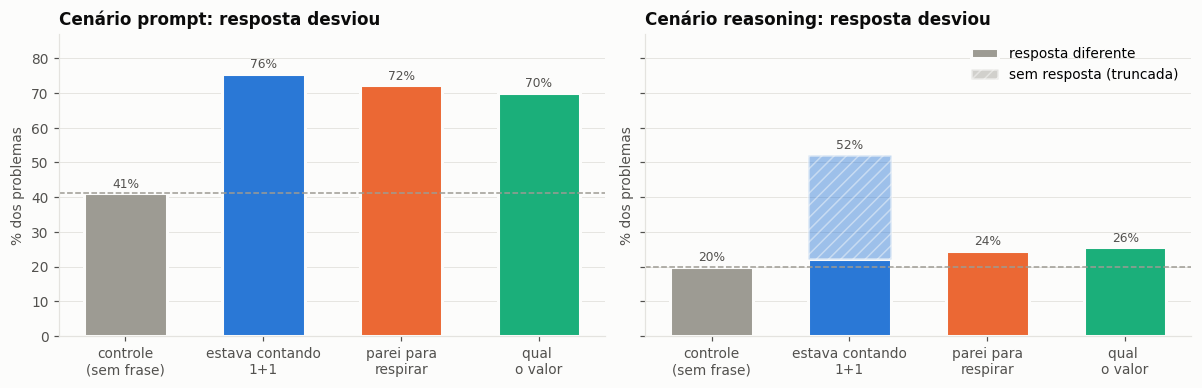

In [5]:
from scipy.stats import fisher_exact

clean = g[g.scenario == "clean"].set_index("instance_id")
g["clean_pred"] = g.instance_id.map(clean.pred_cents)
g["clean_correct"] = g.instance_id.map(clean.correct)
valid = g[g.pred_cents.notna() & g.clean_pred.notna()].copy()
valid["changed"] = valid.pred_cents != valid.clean_pred

# Desvio = resposta diferente OU nenhuma resposta (ex.: geração truncada em loop)
comp = g[g.clean_pred.notna() & (g.condition != "clean")].copy()
comp["desviou"] = comp.pred_cents.isna() | (comp.pred_cents != comp.clean_pred)

order = (["control"] + [f"prompt:{k}" for k in DKEYS]
         + ["reasoning:control"] + [f"reasoning:{k}" for k in DKEYS])
beh = comp.groupby("condition").agg(
    n=("desviou", "size"),
    sem_resposta=("pred_cents", lambda s: s.isna().sum()),
    mudou=("pred_cents", lambda s: 0),
    desviou=("desviou", "sum"),
    acuracia=("correct", "mean"),
).reindex(order)
beh["mudou"] = valid[valid.condition != "clean"].groupby("condition").changed.sum().reindex(order)
beh["taxa_desvio"] = beh.desviou / beh.n
for cond in order:
    ctrl = "control" if cond.startswith(("prompt", "control")) else "reasoning:control"
    if cond != ctrl:
        a, c = beh.loc[cond], beh.loc[ctrl]
        beh.loc[cond, "p_vs_controle"] = fisher_exact([[a.desviou, a.n - a.desviou],
                                                       [c.desviou, c.n - c.desviou]])[1]
beh.loc["clean", ["n", "sem_resposta", "mudou", "desviou", "acuracia", "taxa_desvio"]] = \
    [len(clean), clean.pred_cents.isna().sum(), 0, 0, clean.correct.mean(), 0.0]
display(beh.style.format({"taxa_desvio": "{:.1%}", "acuracia": "{:.1%}", "p_vs_controle": "{:.3f}",
                          "n": "{:.0f}", "sem_resposta": "{:.0f}", "mudou": "{:.0f}", "desviou": "{:.0f}"},
                         na_rep="—"))
print("desviou = resposta diferente da resposta sem frase, ou sem resposta final (truncada);"
      " p = teste exato de Fisher contra o controle do mesmo cenário")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6), sharey=True)
for ax, scen, ctrl in zip(axes, ["prompt", "reasoning"], ["control", "reasoning:control"]):
    rows = [ctrl] + [f"{scen}:{k}" for k in DKEYS]
    x = np.arange(len(rows))
    changed = beh.loc[rows, "mudou"].values / beh.loc[rows, "n"].values * 100
    failed = beh.loc[rows, "sem_resposta"].values / beh.loc[rows, "n"].values * 100
    colors = [CONTROL_COLOR] + [DCOLORS[k] for k in DKEYS]
    ax.bar(x, changed, color=colors, width=0.6, edgecolor=SURF, linewidth=2, label="resposta diferente")
    ax.bar(x, failed, bottom=changed, color=colors, width=0.6, edgecolor=SURF, linewidth=2,
           hatch="///", alpha=0.45, label="sem resposta (truncada)")
    for xi, tot in zip(x, changed + failed):
        ax.annotate(f"{tot:.0f}%", (xi, tot), ha="center", va="bottom", fontsize=8, color=INK2,
                    xytext=(0, 2), textcoords="offset points")
    ax.axhline(changed[0] + failed[0], color=CONTROL_COLOR, linestyle="--", linewidth=1)
    ax.set_xticks(x, ["controle\n(sem frase)"] + [k.replace("_", " ").replace(" 1+1", "\n1+1")
                                                  .replace("para ", "para\n").replace("o valor", "\no valor")
                                                  for k in DKEYS])
    ax.set_ylim(0, max(beh.taxa_desvio.max() * 100 * 1.15, 10))
    ax.set_title(f"Cenário {scen}: resposta desviou")
    ax.set_ylabel("% dos problemas")
    ax.grid(axis="x", visible=False)
axes[1].legend(loc="upper right")
fig.tight_layout()

In [6]:
# Direção da mudança: o distrator estraga acertos ou conserta erros?
def transitions(df):
    return pd.Series({
        "acerto→erro": ((df.clean_correct) & (~df.correct)).sum(),
        "erro→acerto": ((~df.clean_correct.astype(bool)) & (df.correct)).sum(),
        "erro→outro erro": ((~df.clean_correct.astype(bool)) & (~df.correct) & df.changed).sum(),
    })
valid.groupby("condition").apply(transitions, include_groups=False).reindex([c for c in order])

,acerto→erro,erro→acerto,erro→outro erro
condition,,,
control,1,1,35
prompt:estava_contando_1+1,2,0,66
prompt:parei_para_respirar,3,2,60
prompt:qual_o_valor,1,1,61
reasoning:control,0,0,18
reasoning:estava_contando_1+1,1,0,19
reasoning:parei_para_respirar,0,0,22
reasoning:qual_o_valor,0,1,22


**Como ler:** uma frase irrelevante só tem efeito real se a taxa de mudança
ficar **acima do controle** do mesmo cenário. Com decodificação gulosa em lotes,
parte das mudanças é ruído numérico: basta um token diferente para o raciocínio
seguir outro caminho. Se o controle do cenário *prompt* já muda muitas
respostas, a resposta final desses problemas é **instável por si só**, e o
efeito comportamental das frases não pode ser separado do ruído. As seções
seguintes medem o efeito interno, que não tem esse problema.

## 3. Captura das ativações

Uma passada *teacher-forced* por condição (~0,5 s cada). Os resumos ficam em
`captures/<problema>.pt` e também são reaproveitados.

**Referência de ruído numérico (`clean_padded`):** o mesmo texto limpo,
reprocessado com 8 tokens de padding mascarados à esquerda. O modelo vê
exatamente o mesmo texto; só muda a forma dos tensores, o mesmo tipo de
diferença que a geração em lotes introduz. Nos gráficos ela aparece como uma
linha cinza tracejada: **só o que fica acima dela é efeito da frase**.

In [7]:
E.run_capture(model, tok, gens, DISTRACTORS, CAP_DIR, prompt_mode=PROMPT_MODE)
recs = E.load_captures(CAP_DIR)
recs = [r for r in recs if r["instance_id"] in {s["instance_id"] for s in sample}]
CONDS = [c for c in ["clean", "clean_padded"] + [f"{s}:{k}" for s in ("prompt", "reasoning") for k in DKEYS]
         if all(c in r["conditions"] for r in recs)]
print(f"{len(recs)} problemas capturados | condições: {CONDS}")
print("Exemplo de resposta lida:", recs[0]["answer"], recs[0]["answer_tokens"])

capture:   0%|          | 0/90 [00:00<?, ?it/s]

capture:   1%|          | 1/90 [00:03<05:30,  3.71s/it]

capture:   2%|▏         | 2/90 [00:07<05:17,  3.61s/it]

capture:   3%|▎         | 3/90 [00:10<05:07,  3.54s/it]

capture:   4%|▍         | 4/90 [00:14<05:06,  3.56s/it]

...

capture:  98%|█████████▊| 88/90 [06:01<00:09,  4.74s/it]

capture:  99%|█████████▉| 89/90 [06:06<00:04,  4.72s/it]

capture: 100%|██████████| 90/90 [06:10<00:00,  4.59s/it]

capture: 100%|██████████| 90/90 [06:10<00:00,  4.12s/it]

90 problemas capturados | condições: ['clean', 'clean_padded', 'prompt:estava_contando_1+1', 'prompt:parei_para_respirar', 'prompt:qual_o_valor', 'reasoning:estava_contando_1+1', 'reasoning:parei_para_respirar', 'reasoning:qual_o_valor']
Exemplo de resposta lida: 1,365 ['1', ',', '3', '6', '5']


In [8]:
def per_layer(metric):
    # DataFrame (condição, camada) -> média e erro padrão entre problemas
    rows = []
    for r in recs:
        for cond, m in r["compare"].items():
            for layer, v in enumerate(m[metric]):
                rows.append({"condition": cond, "layer": layer, "value": float(v), "instance_id": r["instance_id"]})
    df = pd.DataFrame(rows)
    return df.groupby(["condition", "layer"]).value.agg(["mean", "sem"]).reset_index()

def plot_scenarios(df, ylabel, title, layer_offset=0, ylim=None):
    fig, axes = plt.subplots(1, 2, figsize=(11, 3.4), sharey=True)
    for ax, scen in zip(axes, ["prompt", "reasoning"]):
        shade_band(ax)
        for k in DKEYS:
            d = df[df.condition == f"{scen}:{k}"]
            x = d.layer + layer_offset
            ax.plot(x, d["mean"], color=DCOLORS[k], label=k.replace("_", " "))
            ax.fill_between(x, d["mean"] - d["sem"], d["mean"] + d["sem"], color=DCOLORS[k], alpha=0.15, linewidth=0)
        ref = df[df.condition == "clean_padded"]
        if len(ref):
            ax.plot(ref.layer + layer_offset, ref["mean"], color=CONTROL_COLOR, linestyle="--",
                    linewidth=1.5, label="ruído numérico (mesmo texto)")
        ax.set_title(f"{title}: cenário {scen}")
        ax.set_xlabel("camada")
        ax.set_ylabel(ylabel)
        if ylim:
            ax.set_ylim(*ylim)
    axes[0].legend(loc="best")
    fig.tight_layout()
    return fig

## 4. Fluxo residual: quanto a frase desloca a representação

Distância relativa ‖h_com − h_sem‖ / ‖h_sem‖ do residual nas posições que
produzem a resposta, depois de cada camada. Zero = a frase não mudou nada
naquela camada. A faixa colorida em volta da linha é o erro padrão entre
problemas.

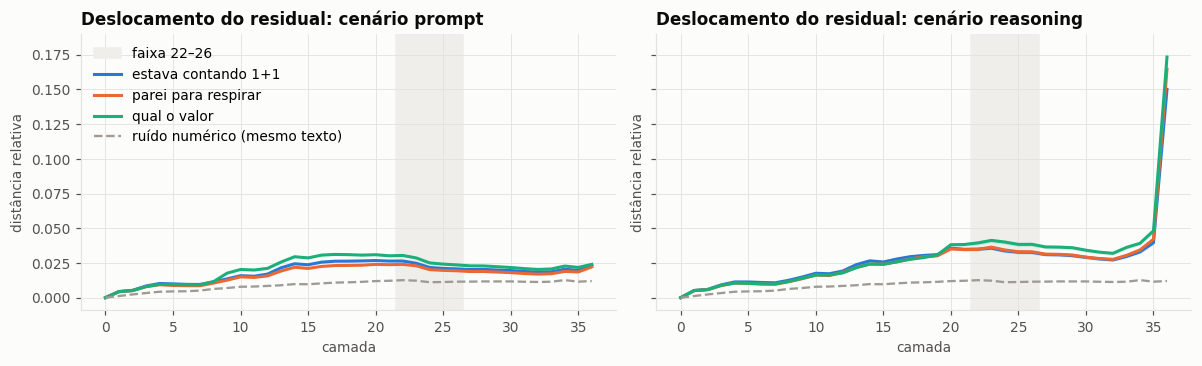

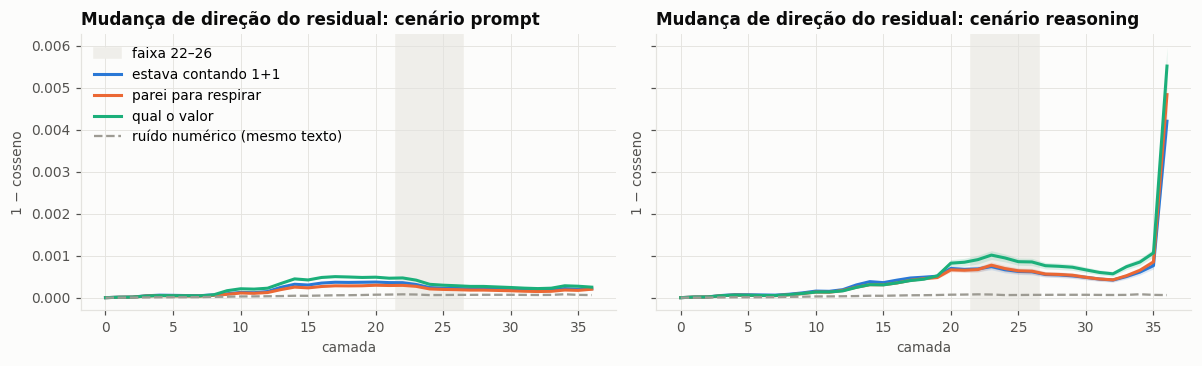

In [9]:
res = per_layer("resid_rel_l2")
plot_scenarios(res, "distância relativa", "Deslocamento do residual")
cos = per_layer("resid_cos")
cos["mean"] = 1 - cos["mean"]
plot_scenarios(cos, "1 − cosseno", "Mudança de direção do residual");

In [10]:
# Onde o deslocamento é máximo, por condição
peak = res.loc[res.groupby("condition")["mean"].idxmax()].set_index("condition")[["layer", "mean"]]
peak.columns = ["camada de pico", "distância no pico"]
band = res[res.layer.between(*BAND)].groupby("condition")["mean"].mean().rename(f"média {BAND[0]}–{BAND[1]}")
final = res[res.layer == N_LAYERS].set_index("condition")["mean"].rename("na última camada")
pd.concat([peak, band, final], axis=1).style.format({"distância no pico": "{:.3f}", f"média {BAND[0]}–{BAND[1]}": "{:.3f}", "na última camada": "{:.3f}"})

,camada de pico,distância no pico,média 22–26,na última camada
condition,,,,
clean_padded,34,0.013,0.012,0.012
prompt:estava_contando_1+1,20,0.027,0.023,0.023
prompt:parei_para_respirar,20,0.024,0.021,0.022
prompt:qual_o_valor,17,0.031,0.026,0.024
reasoning:estava_contando_1+1,36,0.150,0.034,0.150
reasoning:parei_para_respirar,36,0.164,0.034,0.164
reasoning:qual_o_valor,36,0.173,0.039,0.173


## 5. Logit lens: em que camada a resposta aparece

Para cada camada, aplicamos a normalização final e o *unembedding* ao residual
e medimos a probabilidade dos dígitos da resposta. A curva mostra **como a
resposta vai sendo construída** ao longo da profundidade. Se a frase
atrapalha, a curva da condição com frase fica abaixo ou deslocada para a direita.

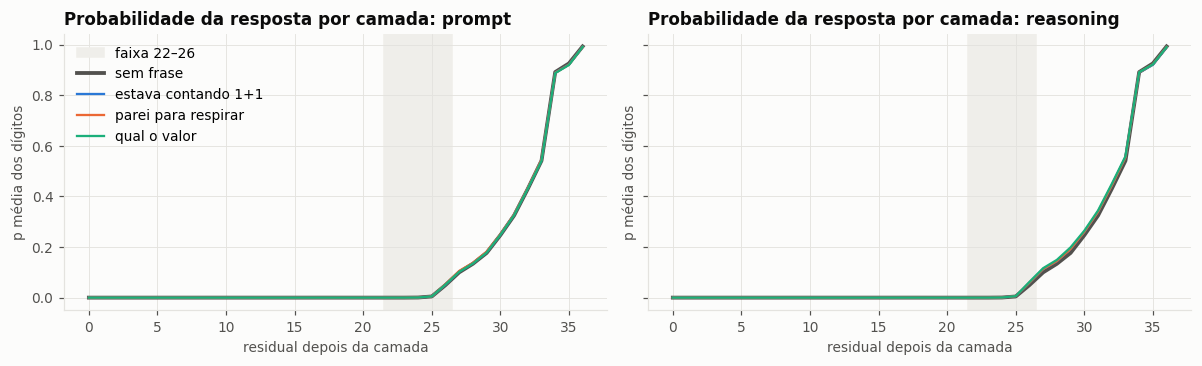

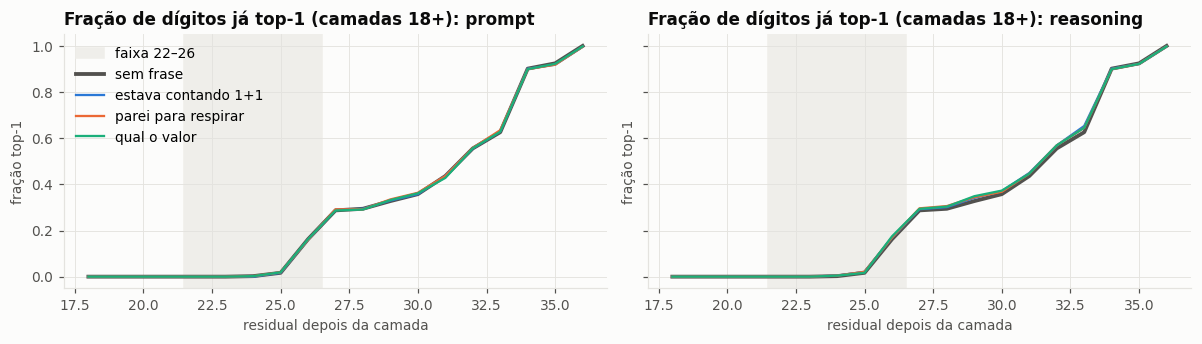

In [11]:
lens_rows = []
for r in recs:
    for cond in CONDS:
        s = r["conditions"][cond]
        p = np.exp(s["target_logp"]).mean(axis=1)            # média sobre os dígitos
        top1 = (s["target_rank"] == 0).mean(axis=1)
        for layer in range(len(p)):
            lens_rows.append({"instance_id": r["instance_id"], "condition": cond, "layer": layer,
                              "p_answer": p[layer], "top1_frac": top1[layer]})
lens = pd.DataFrame(lens_rows)
lm = lens.groupby(["condition", "layer"]).agg(p=("p_answer", "mean"), top1=("top1_frac", "mean")).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(11, 3.4), sharey=True)
for ax, scen in zip(axes, ["prompt", "reasoning"]):
    shade_band(ax)
    d = lm[lm.condition == "clean"]
    ax.plot(d.layer, d.p, color=CLEAN_COLOR, linewidth=2.5, label="sem frase")
    for k in DKEYS:
        d = lm[lm.condition == f"{scen}:{k}"]
        ax.plot(d.layer, d.p, color=DCOLORS[k], linewidth=1.5, label=k.replace("_", " "))
    ax.set_title(f"Probabilidade da resposta por camada: {scen}")
    ax.set_xlabel("residual depois da camada")
    ax.set_ylabel("p média dos dígitos")
axes[0].legend(loc="upper left")
fig.tight_layout()

# Zoom nas camadas finais, onde as curvas se separam
fig, axes = plt.subplots(1, 2, figsize=(11, 3.2), sharey=True)
for ax, scen in zip(axes, ["prompt", "reasoning"]):
    shade_band(ax)
    for cond, color, lw in [("clean", CLEAN_COLOR, 2.5)] + [(f"{scen}:{k}", DCOLORS[k], 1.5) for k in DKEYS]:
        d = lm[(lm.condition == cond) & (lm.layer >= 18)]
        ax.plot(d.layer, d.top1, color=color, linewidth=lw,
                label="sem frase" if cond == "clean" else cond.split(":")[1].replace("_", " "))
    ax.set_title(f"Fração de dígitos já top-1 (camadas 18+): {scen}")
    ax.set_xlabel("residual depois da camada")
    ax.set_ylabel("fração top-1")
axes[0].legend(loc="upper left")
fig.tight_layout()

### 5.1 Camada de convergência

Primeira camada a partir da qual **todos** os dígitos da resposta são a
predição top-1 até a última camada: é onde a resposta "fecha". Comparamos a
distribuição sem e com a frase, e a diferença problema a problema.

,mediana,média,% em 22–26,Δ médio vs sem frase,% problemas com Δ≠0
condition,,,,,
clean,34.0,34.71,0.0,0.00,0.00
clean_padded,34.0,34.72,0.0,0.01,1.11
prompt:estava_contando_1+1,34.0,34.74,0.0,0.03,4.44
prompt:parei_para_respirar,34.0,34.74,0.0,0.03,4.44
prompt:qual_o_valor,34.0,34.72,0.0,0.02,5.56
reasoning:estava_contando_1+1,34.0,34.70,0.0,0.00,5.56
reasoning:parei_para_respirar,34.0,34.72,0.0,0.02,3.33
reasoning:qual_o_valor,34.0,34.72,0.0,0.02,5.56


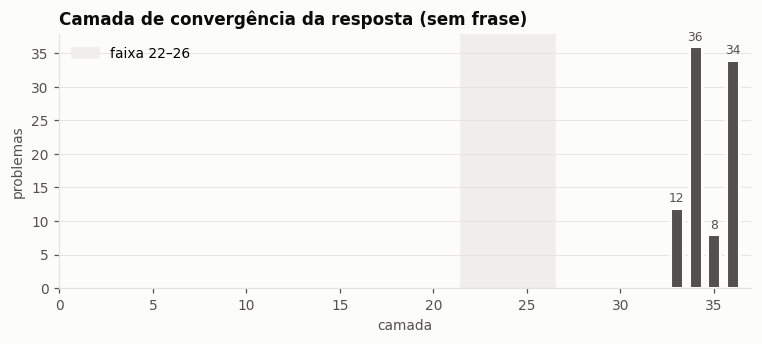

In [12]:
conv = pd.DataFrame([{"instance_id": r["instance_id"], "condition": c,
                      "conv": r["conditions"][c]["convergence_layer"]}
                     for r in recs for c in CONDS])
wide = conv.pivot(index="instance_id", columns="condition", values="conv")
summary = pd.DataFrame({
    "mediana": wide.median(),
    "média": wide.mean(),
    f"% em {BAND[0]}–{BAND[1]}": wide.apply(lambda s: s.between(*BAND).mean() * 100),
    "Δ médio vs sem frase": wide.sub(wide["clean"], axis=0).mean(),
    "% problemas com Δ≠0": wide.sub(wide["clean"], axis=0).ne(0).mean() * 100,
}).reindex(CONDS)
display(summary.round(2))

fig, ax = plt.subplots(figsize=(7, 3.2))
shade_band(ax)
vc = wide["clean"].value_counts().sort_index()
bars = ax.bar(vc.index, vc.values, color=CLEAN_COLOR, width=0.7, edgecolor=SURF, linewidth=2)
bar_labels(ax, bars)
ax.set_title("Camada de convergência da resposta (sem frase)")
ax.set_xlabel("camada")
ax.set_ylabel("problemas")
ax.set_xlim(0, N_LAYERS + 1)
ax.legend(loc="upper left")
ax.grid(axis="x", visible=False)
fig.tight_layout()

### 5.2 A resposta correta camada a camada

Até aqui lemos a resposta **que o modelo deu**. Agora lemos a **resposta
correta** (o gabarito): o raciocínio de cada condição é reapresentado e, no
lugar da resposta do modelo, colocamos o valor certo.

**Ponto de decisão:** o primeiro dígito em que a resposta do modelo e o
gabarito divergem (ex.: gabarito $1,**2**45 × modelo $1,**3**65, 3º token).
Até ali o contexto é idêntico, então é nessa posição que o modelo "escolhe"
errado. Nela medimos, camada a camada:
- **p(correto)** e **rank(correto)**: probabilidade e posição do dígito certo
  (rank 0 = seria escolhido);
- **p(escolhido)**: probabilidade do dígito que o modelo de fato escolheu;
- o **top-1** de cada camada.

Nos problemas que o modelo acerta não há ponto de decisão; neles usamos o
primeiro dígito.

In [13]:
E.run_gold_capture(model, tok, gens, DISTRACTORS, CAP_DIR, prompt_mode=PROMPT_MODE)
recs = [r for r in E.load_captures(CAP_DIR) if r["instance_id"] in {s["instance_id"] for s in sample}]
GCONDS = [c for c in CONDS if all(c in r["gold"]["conditions"] for r in recs)]

def dec_pos(r):
    j = r["gold"]["divergence"]
    return 0 if j is None else j

# Tabela longa: problema × condição × camada, no ponto de decisão
drows = []
for r in recs:
    G, j = r["gold"], dec_pos(r)
    for cond in GCONDS:
        s = G["conditions"][cond]
        for layer in range(N_LAYERS + 1):
            drows.append({"instance_id": r["instance_id"], "condition": cond, "layer": layer,
                          "rank_gold": int(s["target_rank"][layer, j]),
                          "p_gold": float(np.exp(s["target_logp"][layer, j])),
                          "p_pred": float(np.exp(s["alt_logp"][layer, j])),
                          "acertou": G["divergence"] is None})
dec = pd.DataFrame(drows)
n_ok = sum(r["gold"]["divergence"] is None for r in recs)
print(f"{len(recs)} problemas | o modelo acerta {n_ok} (sem frase, raciocínio reapresentado) | "
      f"{len(recs) - n_ok} têm ponto de decisão")

gold capture:   0%|          | 0/90 [00:00<?, ?it/s]

gold capture:   1%|          | 1/90 [00:03<05:25,  3.65s/it]

gold capture:   2%|▏         | 2/90 [00:07<05:15,  3.58s/it]

gold capture:   3%|▎         | 3/90 [00:10<05:06,  3.52s/it]

gold capture:   4%|▍         | 4/90 [00:14<05:05,  3.55s/it]

...

gold capture:  98%|█████████▊| 88/90 [06:01<00:09,  4.74s/it]

gold capture:  99%|█████████▉| 89/90 [06:06<00:04,  4.72s/it]

gold capture: 100%|██████████| 90/90 [06:10<00:00,  4.60s/it]

gold capture: 100%|██████████| 90/90 [06:10<00:00,  4.12s/it]

90 problemas | o modelo acerta 3 (sem frase, raciocínio reapresentado) | 87 têm ponto de decisão


**Resposta selecionada × gabarito, por problema.** As respostas vêm da
geração livre de cada condição. O *rank final* é a posição do dígito correto,
no ponto de decisão, na última camada: 0 = seria escolhido, 1 = segundo
colocado etc.

In [14]:
ans = valid.pivot_table(index="instance_id", columns="condition", values="pred_cents", aggfunc="first") / 100
show_conds = ["clean", "control"] + [f"{sc}:{DKEYS[1]}" for sc in ("prompt", "reasoning")]
final = dec[dec.layer == N_LAYERS].pivot(index="instance_id", columns="condition", values="rank_gold")
overview = []
for r in recs:
    G, j = r["gold"], r["gold"]["divergence"]
    row = {"problema": r["instance_id"], "gabarito": f"${G['answer']}"}
    for c in show_conds:
        v = ans.loc[r["instance_id"]].get(c, np.nan) if r["instance_id"] in ans.index else np.nan
        row[f"resposta {c}"] = "—" if pd.isna(v) else f"${v:,.0f}"
    row["ponto de decisão"] = ("acertou" if j is None else
                               f"token {j + 1}: certo {G['tokens'][j] if j < len(G['tokens']) else '∅'!r}"
                               f" × escolhido {G['alt_tokens'][j]!r}")
    for c in ["clean", "clean_padded"] + [f"{sc}:{DKEYS[1]}" for sc in ("prompt", "reasoning")]:
        row[f"rank final {c}"] = int(final.loc[r["instance_id"], c])
    overview.append(row)
pd.DataFrame(overview).set_index("problema")

,gabarito,resposta clean,resposta control,resposta prompt:parei_para_respirar,resposta reasoning:parei_para_respirar,ponto de decisão,rank final clean,rank final clean_padded,rank final prompt:parei_para_respirar,rank final reasoning:parei_para_respirar
problema,,,,,,,,,,
c0_000,"$1,245","$1,365","$1,365","$1,365","$1,365",token 3: certo '2' × escolhido '3',2,2,2,2
c0_003,"$1,513","$1,513","$1,513","$1,563","$1,513",acertou,0,0,0,0
c0_004,"$1,434","$1,434","$1,434","$1,684","$1,434",acertou,0,0,0,0
c0_011,"$1,203","$1,278","$1,278","$1,278","$1,278",token 4: certo '0' × escolhido '7',6,6,6,6
c0_013,"$1,097","$1,282","$1,282","$1,337","$1,282",token 3: certo '0' × escolhido '2',3,3,3,3
...,...,...,...,...,...,...,...,...,...,...
c2_084,"$3,114","$3,049","$2,949","$1,999","$3,049",token 3: certo '1' × escolhido '0',2,2,2,2
c2_088,$3324,"$2,464","$2,464","$2,304","$2,464",token 1: certo '3' × escolhido '2',1,1,1,1
c2_093,"$3,204","$3,539","$3,539","$3,539","$3,439",token 3: certo '2' × escolhido '5',1,1,1,1


,problemas,rank mediano,% rank 0 (escolheria certo),% top-2,% top-5,p(correto) média,p(escolhido) média
condition,,,,,,,
clean,87,2.0,0.0,31.034,78.161,0.0,0.995
clean_padded,87,2.0,0.0,31.034,77.011,0.0,0.994
prompt:estava_contando_1+1,87,2.0,0.0,31.034,77.011,0.0,0.992
prompt:parei_para_respirar,87,2.0,0.0,31.034,77.011,0.0,0.993
prompt:qual_o_valor,87,2.0,0.0,31.034,75.862,0.0,0.996
reasoning:estava_contando_1+1,87,2.0,0.0,32.184,74.713,0.0,0.994
reasoning:parei_para_respirar,87,2.0,0.0,32.184,75.862,0.0,0.996
reasoning:qual_o_valor,87,2.0,0.0,32.184,74.713,0.0,0.997


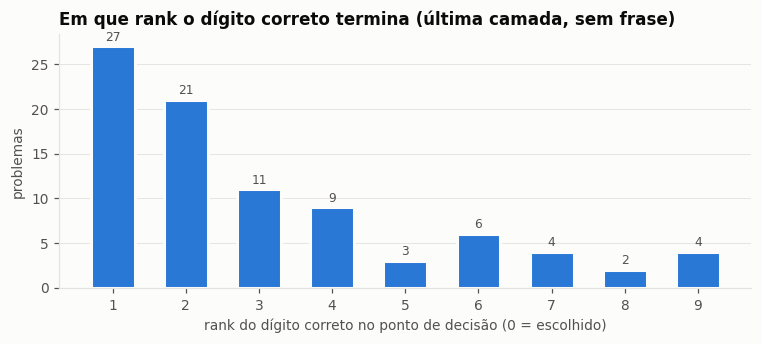

In [15]:
# Resumo por condição, na última camada e no ponto de decisão (só problemas com erro)
last = dec[(dec.layer == N_LAYERS) & (~dec.acertou)]
summary_gold = last.groupby("condition").agg(
    problemas=("rank_gold", "size"),
    rank_mediano=("rank_gold", "median"),
    pct_rank0=("rank_gold", lambda s: (s == 0).mean() * 100),
    pct_top2=("rank_gold", lambda s: (s <= 1).mean() * 100),
    pct_top5=("rank_gold", lambda s: (s <= 4).mean() * 100),
    p_correto=("p_gold", "mean"),
    p_escolhido=("p_pred", "mean"),
).reindex(GCONDS)
summary_gold.columns = ["problemas", "rank mediano", "% rank 0 (escolheria certo)", "% top-2", "% top-5",
                        "p(correto) média", "p(escolhido) média"]
display(summary_gold.round(3))

# Distribuição do rank final do dígito correto, sem frase
fig, ax = plt.subplots(figsize=(7, 3.2))
vc = last[last.condition == "clean"].rank_gold.clip(upper=10).value_counts().sort_index()
bars = ax.bar(vc.index.astype(int).astype(str).str.replace("10", "10+"), vc.values, color="#2a78d6",
              width=0.6, edgecolor=SURF, linewidth=2)
bar_labels(ax, bars)
ax.set_title("Em que rank o dígito correto termina (última camada, sem frase)")
ax.set_xlabel("rank do dígito correto no ponto de decisão (0 = escolhido)")
ax.set_ylabel("problemas")
ax.grid(axis="x", visible=False)
fig.tight_layout()

**Probabilidade e rank do dígito correto ao longo das camadas.** À esquerda,
p(correto) × p(escolhido) sem frase: a camada em que a curva do escolhido
passa a do correto é onde a decisão errada se forma. À direita, o rank mediano
do dígito correto (escala log) em cada condição.

Camada em que o dígito escolhido (errado) passa o correto e não perde mais a frente:


,mediana,média,% em 22–26
condition,,,
clean,24.0,22.7,72.4
clean_padded,24.0,22.8,73.6
prompt:estava_contando_1+1,24.0,22.8,73.6
prompt:parei_para_respirar,24.0,22.7,73.6
prompt:qual_o_valor,24.0,22.6,73.6
reasoning:estava_contando_1+1,24.0,22.8,74.7
reasoning:parei_para_respirar,24.0,22.7,74.7
reasoning:qual_o_valor,24.0,22.8,74.7


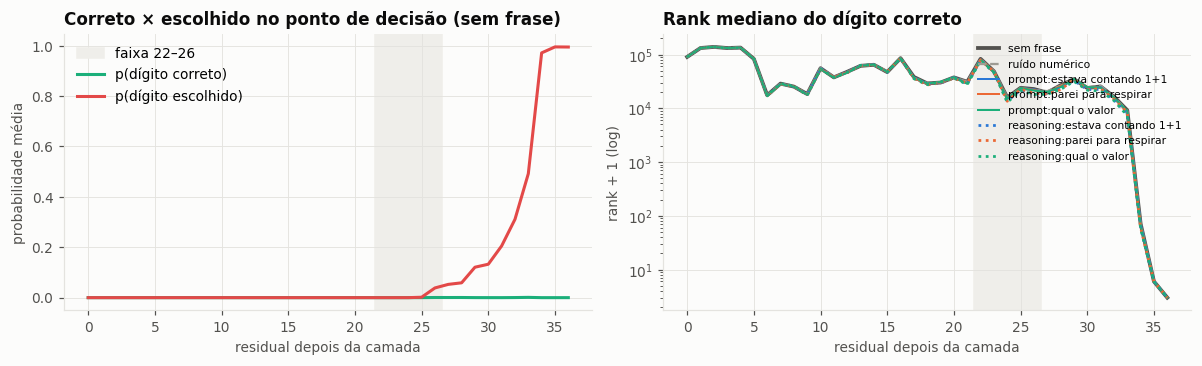

In [16]:
err = dec[~dec.acertou]
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
ax = axes[0]
shade_band(ax)
m = err[err.condition == "clean"].groupby("layer")[["p_gold", "p_pred"]].mean()
ax.plot(m.index, m.p_gold, color="#1baf7a", label="p(dígito correto)")
ax.plot(m.index, m.p_pred, color="#e34948", label="p(dígito escolhido)")
ax.set_title("Correto × escolhido no ponto de decisão (sem frase)")
ax.set_xlabel("residual depois da camada")
ax.set_ylabel("probabilidade média")
ax.legend(loc="upper left")

ax = axes[1]
shade_band(ax, label=False)
for cond, color, ls, lw in ([("clean", CLEAN_COLOR, "-", 2.5), ("clean_padded", CONTROL_COLOR, "--", 1.5)]
                            + [(f"prompt:{k}", DCOLORS[k], "-", 1.3) for k in DKEYS]
                            + [(f"reasoning:{k}", DCOLORS[k], ":", 1.8) for k in DKEYS]):
    if cond not in GCONDS:
        continue
    med = err[err.condition == cond].groupby("layer").rank_gold.median()
    ax.plot(med.index, med.values + 1, color=color, linestyle=ls, linewidth=lw,
            label={"clean": "sem frase", "clean_padded": "ruído numérico"}.get(cond, cond.replace("_", " ")))
ax.set_yscale("log")
ax.set_title("Rank mediano do dígito correto")
ax.set_xlabel("residual depois da camada")
ax.set_ylabel("rank + 1 (log)")
ax.legend(loc="upper right", fontsize=7, ncol=1)
fig.tight_layout()

# Camada em que o escolhido passa o correto de vez
def crossover(g):
    ahead = (g.sort_values("layer").p_pred > g.sort_values("layer").p_gold).values
    if not ahead[-1]:
        return np.nan
    k = len(ahead) - 1
    while k > 0 and ahead[k - 1]:
        k -= 1
    return k
cross = err.groupby(["condition", "instance_id"]).apply(crossover, include_groups=False).unstack(0)
print("Camada em que o dígito escolhido (errado) passa o correto e não perde mais a frente:")
display(pd.DataFrame({"mediana": cross.median(), "média": cross.mean(),
                      f"% em {BAND[0]}–{BAND[1]}": cross.apply(lambda s: s.between(*BAND).mean() * 100)})
        .reindex(GCONDS).round(1))

**Camada a camada, para um problema.** Para cada condição: o top-1 da camada
(com probabilidade), p(correto), rank(correto) e p(escolhido), no ponto de
decisão. Mostramos o problema em que o dígito correto chegou mais perto de
ser escolhido sem frase.

In [17]:
def show_layers(rec, conds, layers=range(16, N_LAYERS + 1)):
    G, j = rec["gold"], dec_pos(rec)
    print(f"Problema {rec['instance_id']} | gabarito ${G['answer']} | resposta do modelo ${rec['answer']} | "
          f"ponto de decisão: token {j + 1} (correto {G['tokens'][j]!r} × escolhido {G['alt_tokens'][j]!r})")
    cols = {}
    for cond in conds:
        s = G["conditions"][cond]
        name = {"clean": "sem frase", "clean_padded": "ruído numérico"}.get(cond, cond)
        cols[(name, "top-1")] = [f"{tok.decode([int(s['top_ids'][l, j, 0])])!r} {np.exp(s['top_logp'][l, j, 0]):.2f}"
                                 for l in layers]
        cols[(name, "p(correto)")] = [np.exp(s["target_logp"][l, j]) for l in layers]
        cols[(name, "rank")] = [int(s["target_rank"][l, j]) for l in layers]
        cols[(name, "p(escolhido)")] = [np.exp(s["alt_logp"][l, j]) for l in layers]
    df = pd.DataFrame(cols, index=[f"camada {l}" for l in layers])
    fmt = {c: "{:.3f}" for c in df.columns if c[1] in ("p(correto)", "p(escolhido)")}
    return df.style.format(fmt).background_gradient(
        subset=[c for c in df.columns if c[1] == "p(correto)"], cmap="Greens", vmin=0, vmax=1)

with_err = [r for r in recs if r["gold"]["divergence"] is not None]
if with_err:
    closest = min(with_err, key=lambda r: (int(final.loc[r["instance_id"], "clean"]),
                                          -float(np.exp(r["gold"]["conditions"]["clean"]["target_logp"][-1, dec_pos(r)]))))
    display(show_layers(closest, ["clean", "clean_padded", f"prompt:{DKEYS[1]}", f"reasoning:{DKEYS[1]}"]))

Problema c2_035 | gabarito $2,937 | resposta do modelo $3,062 | ponto de decisão: token 1 (correto '2' × escolhido '3')


In [18]:
# Outro exemplo: o problema em que a frase mais mudou a probabilidade do dígito correto
def gold_shift(r, cond):
    s0, s1 = r["gold"]["conditions"]["clean"], r["gold"]["conditions"][cond]
    j = dec_pos(r)
    return abs(np.exp(s1["target_logp"][-1, j]) - np.exp(s0["target_logp"][-1, j]))

if with_err:
    cand = [(gold_shift(r, c), r, c) for r in with_err for c in GCONDS if c.startswith(("prompt", "reasoning"))]
    _, most, cond = max(cand, key=lambda t: t[0])
    print(f"Maior mudança de p(correto) na última camada: condição {cond}")
    display(show_layers(most, ["clean", "clean_padded", cond]))

Maior mudança de p(correto) na última camada: condição reasoning:qual_o_valor
Problema c2_035 | gabarito $2,937 | resposta do modelo $3,062 | ponto de decisão: token 1 (correto '2' × escolhido '3')


## 6. Camadas amplificadoras

**Atribuição direta ao logit (DLA):** quanto a saída da atenção e da MLP de
cada camada empurra o logit do dígito correto, em relação ao logit médio do
vocabulário. As camadas com maior DLA são as que **amplificam** a resposta.
Primeiro a condição sem frase; depois, quanto a frase muda cada camada.

Camadas amplificadoras (maior DLA total, sem frase):


,camada,attn,mlp,total
0,36,2.64,8.74,11.38
1,35,5.42,4.30,9.72
2,34,0.98,5.81,6.79
3,33,0.45,1.49,1.94
4,32,-0.03,1.05,1.02
5,31,0.57,0.41,0.98
6,30,0.19,0.60,0.80
7,26,0.01,0.64,0.65


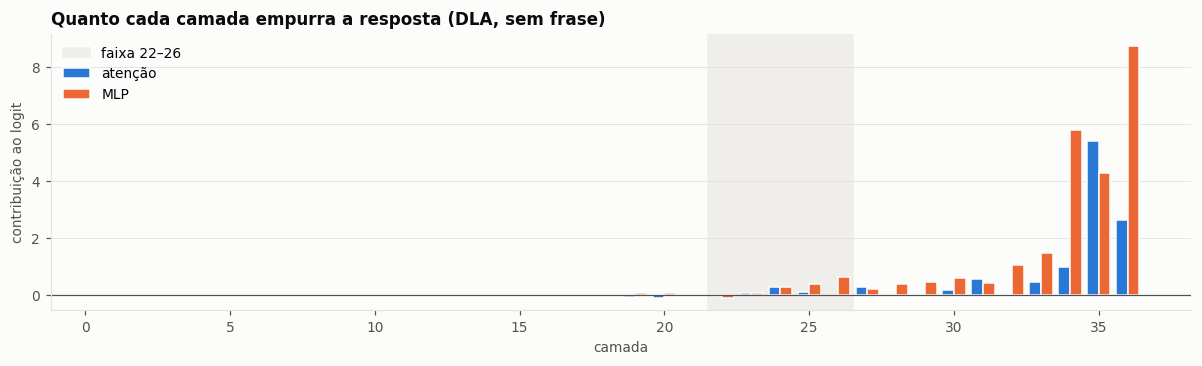

In [19]:
dla_rows = []
for r in recs:
    for cond in CONDS:
        s = r["conditions"][cond]
        for layer in range(N_LAYERS):
            dla_rows.append({"instance_id": r["instance_id"], "condition": cond, "layer": layer + 1,
                             "attn": s["dla_attn"][layer].mean(), "mlp": s["dla_mlp"][layer].mean()})
dla = pd.DataFrame(dla_rows)
dla["total"] = dla.attn + dla.mlp
dm = dla.groupby(["condition", "layer"])[["attn", "mlp", "total"]].mean().reset_index()

d = dm[dm.condition == "clean"]
fig, ax = plt.subplots(figsize=(11, 3.4))
shade_band(ax)
w = 0.4
ax.bar(d.layer - w / 2, d.attn, width=w, color="#2a78d6", label="atenção", edgecolor=SURF, linewidth=1)
ax.bar(d.layer + w / 2, d.mlp, width=w, color="#eb6834", label="MLP", edgecolor=SURF, linewidth=1)
ax.axhline(0, color=INK2, linewidth=0.8)
ax.set_title("Quanto cada camada empurra a resposta (DLA, sem frase)")
ax.set_xlabel("camada")
ax.set_ylabel("contribuição ao logit")
ax.legend(loc="upper left")
ax.grid(axis="x", visible=False)
fig.tight_layout()

top = d.nlargest(8, "total")[["layer", "attn", "mlp", "total"]].rename(columns={"layer": "camada"})
print("Camadas amplificadoras (maior DLA total, sem frase):")
display(top.round(2).reset_index(drop=True))

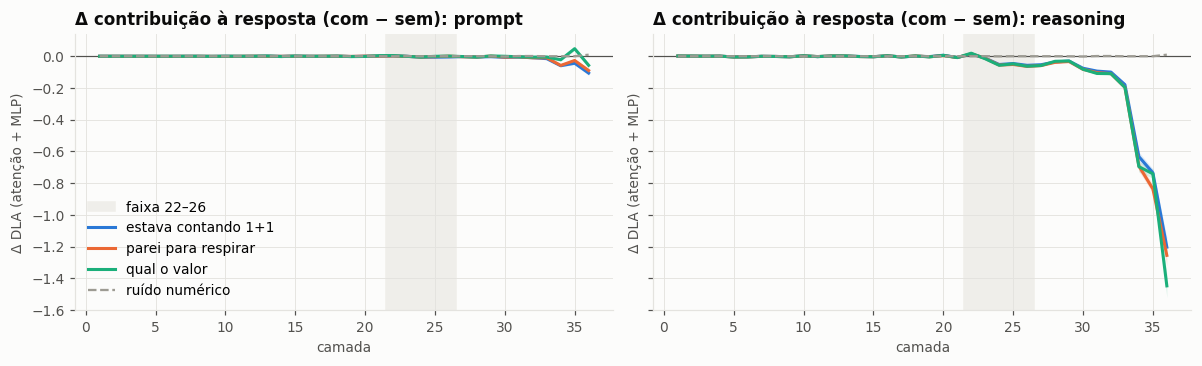

In [20]:
# Mudança da DLA causada pela frase: (com frase) − (sem frase), por camada
base = dla[dla.condition == "clean"].set_index(["instance_id", "layer"])[["attn", "mlp", "total"]]
delta_rows = []
for cond in CONDS[1:]:
    x = dla[dla.condition == cond].set_index(["instance_id", "layer"])[["attn", "mlp", "total"]]
    dd = (x - base).reset_index()
    dd["condition"] = cond
    delta_rows.append(dd)
ddla = pd.concat(delta_rows).groupby(["condition", "layer"])[["attn", "mlp", "total"]].agg(["mean", "sem"])

fig, axes = plt.subplots(1, 2, figsize=(11, 3.4), sharey=True)
for ax, scen in zip(axes, ["prompt", "reasoning"]):
    shade_band(ax)
    ax.axhline(0, color=INK2, linewidth=0.8)
    for k in DKEYS:
        s = ddla.loc[f"{scen}:{k}"]["total"]
        ax.plot(s.index, s["mean"], color=DCOLORS[k], label=k.replace("_", " "))
        ax.fill_between(s.index, s["mean"] - s["sem"], s["mean"] + s["sem"], color=DCOLORS[k], alpha=0.15, linewidth=0)
    if "clean_padded" in ddla.index.get_level_values(0):
        s = ddla.loc["clean_padded"]["total"]
        ax.plot(s.index, s["mean"], color=CONTROL_COLOR, linestyle="--", linewidth=1.5, label="ruído numérico")
    ax.set_title(f"Δ contribuição à resposta (com − sem): {scen}")
    ax.set_xlabel("camada")
    ax.set_ylabel("Δ DLA (atenção + MLP)")
axes[0].legend(loc="lower left")
fig.tight_layout()

**Como ler:** valores negativos significam que, com a frase, aquela camada
empurra **menos** a resposta correta. Se a frase atrapalha de verdade, a queda
se concentra nas camadas amplificadoras da tabela acima.

## 7. Neurônios da MLP

Para cada camada, na posição que produz o primeiro dígito da resposta:
- **sobreposição dos mais ativos**: Jaccard entre o 1% de neurônios de maior
  |ativação| sem e com a frase (123 de 12 288 no Qwen3-8B). 1 = os mesmos neurônios.
- **mudança relativa das ativações** da MLP: ‖a_com − a_sem‖ / ‖a_sem‖.
- **neurônios fortemente alterados**: quantos mudam mais de 3 desvios-padrão
  (desvio das ativações da própria camada, sem frase).

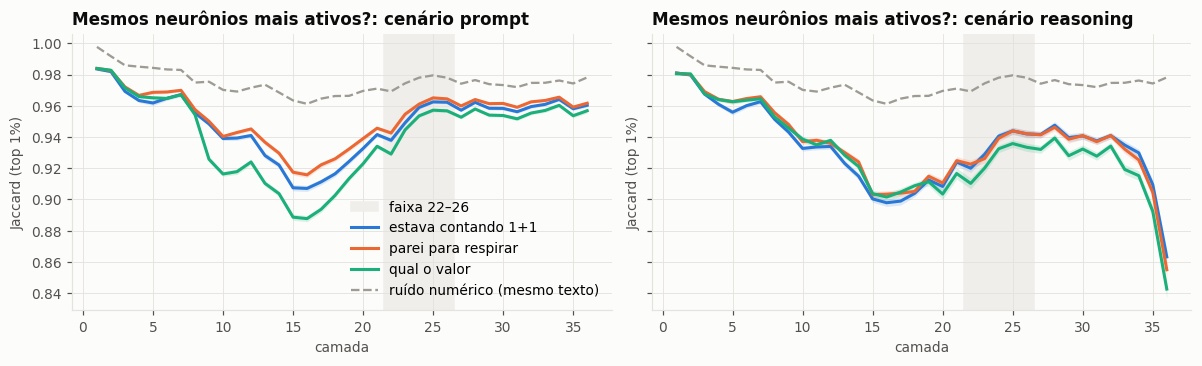

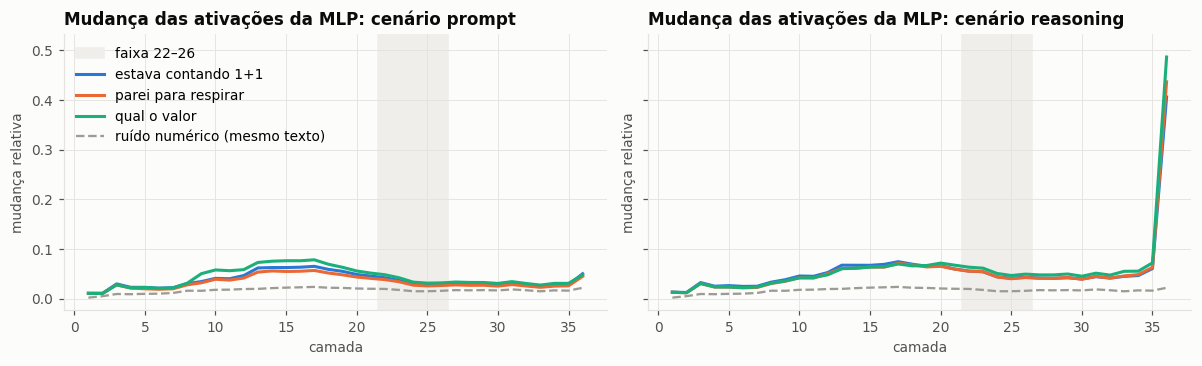

In [21]:
plot_scenarios(per_layer("neuron_jaccard"), "Jaccard (top 1%)", "Mesmos neurônios mais ativos?", layer_offset=1)
plot_scenarios(per_layer("mlp_rel_l2"), "mudança relativa", "Mudança das ativações da MLP", layer_offset=1);

Neurônios com maior |Δ ativação| médio (camada·neurônio):


,clean_padded,prompt:estava_contando_1+1,prompt:parei_para_respirar,prompt:qual_o_valor,reasoning:estava_contando_1+1,reasoning:parei_para_respirar,reasoning:qual_o_valor
0,L36·n9510,L36·n9510,L36·n9510,L36·n9510,L36·n9510,L36·n9510,L36·n9510
1,L36·n8724,L36·n8724,L34·n4117,L34·n4117,L36·n8724,L36·n8724,L36·n8724
2,L34·n4117,L34·n4117,L36·n8724,L36·n8724,L36·n5416,L36·n5416,L36·n11693
3,L34·n4496,L36·n5416,L36·n6412,L34·n4496,L36·n11693,L36·n11333,L36·n5416
4,L36·n11693,L34·n4496,L36·n5416,L36·n11693,L36·n11333,L36·n11693,L36·n11333
5,L36·n3257,L36·n6412,L34·n4496,L36·n9014,L36·n9014,L36·n9014,L36·n7352
6,L36·n6412,L36·n11693,L36·n11693,L36·n9490,L36·n11457,L36·n11457,L36·n11457
7,L35·n25,L36·n11333,L36·n11333,L36·n6412,L36·n5604,L36·n5604,L36·n5604
8,L36·n5416,L35·n25,L36·n8545,L36·n5416,L36·n7352,L36·n3257,L36·n9014
9,L36·n9014,L34·n5613,L34·n5613,L35·n25,L36·n9490,L36·n7352,L36·n8602


Sobreposição dos 100 neurônios mais afetados entre condições:


,clean_padded,prompt:estava_contando_1+1,prompt:parei_para_respirar,prompt:qual_o_valor,reasoning:estava_contando_1+1,reasoning:parei_para_respirar,reasoning:qual_o_valor
clean_padded,100,91,86,82,49,47,51
prompt:estava_contando_1+1,91,100,89,85,50,47,52
prompt:parei_para_respirar,86,89,100,81,50,48,51
prompt:qual_o_valor,82,85,81,100,49,48,53
reasoning:estava_contando_1+1,49,50,50,49,100,92,91
reasoning:parei_para_respirar,47,47,48,48,92,100,88
reasoning:qual_o_valor,51,52,51,53,91,88,100


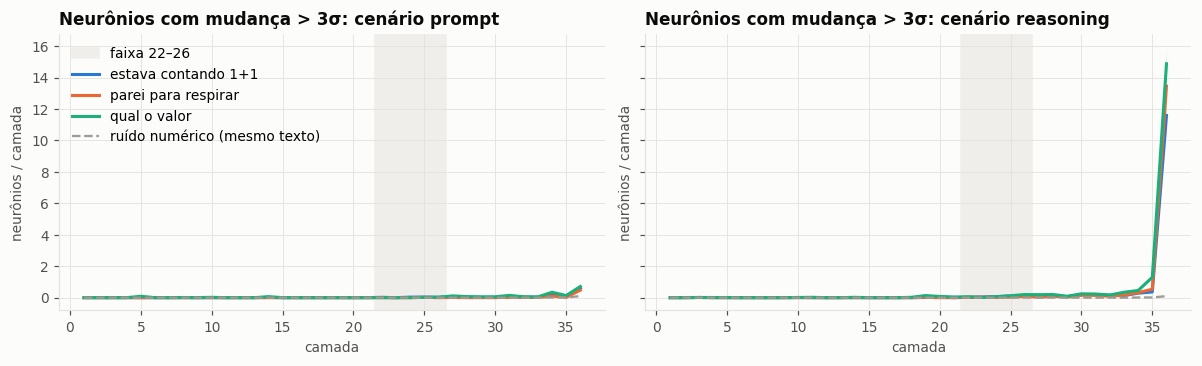

In [22]:
# Neurônios fortemente alterados (> 3σ) e neurônios afetados de forma consistente
strong_rows = []
mean_abs_delta = {c: torch.zeros(N_LAYERS, cfg.intermediate_size) for c in CONDS[1:]}
for r in recs:
    a0 = r["conditions"]["clean"]["mlp_act_pos0"].float()                 # [L, d_ff]
    sigma = a0.std(dim=1, keepdim=True)
    for cond in CONDS[1:]:
        delta = r["conditions"][cond]["mlp_act_pos0"].float() - a0
        mean_abs_delta[cond] += delta.abs() / len(recs)
        n_strong = (delta.abs() > 3 * sigma).sum(1)
        for layer, n in enumerate(n_strong.tolist()):
            strong_rows.append({"condition": cond, "layer": layer, "value": n})
strong = pd.DataFrame(strong_rows).groupby(["condition", "layer"]).value.agg(["mean", "sem"]).reset_index()
plot_scenarios(strong, "neurônios / camada", "Neurônios com mudança > 3σ", layer_offset=1)

# Top-20 neurônios mais afetados em média, por condição
tops = {}
for cond, m in mean_abs_delta.items():
    flat = m.flatten().topk(20)
    tops[cond] = [(int(i) // cfg.intermediate_size + 1, int(i) % cfg.intermediate_size) for i in flat.indices]
top_df = pd.DataFrame({c: [f"L{l}·n{n}" for l, n in v] for c, v in tops.items()})
print("Neurônios com maior |Δ ativação| médio (camada·neurônio):")
display(top_df.head(10))

# Os mesmos neurônios reagem a frases diferentes? (sobreposição dos top-100)
top100 = {c: set(m.flatten().topk(100).indices.tolist()) for c, m in mean_abs_delta.items()}
ov = pd.DataFrame([[len(top100[a] & top100[b]) for b in top100] for a in top100],
                  index=list(top100), columns=list(top100))
print("Sobreposição dos 100 neurônios mais afetados entre condições:")
display(ov)

Se os mesmos neurônios aparecem para frases e cenários diferentes, eles
respondem a *qualquer* interrupção irrelevante, não ao conteúdo específico da
frase. São candidatos a análise causal (ablação ou *patching*).

## 8. O que cada camada gera

Decodificação do residual pelo logit lens na posição que produz o **primeiro
dígito** da resposta, para um problema. A tabela mostra, camada a camada, o
token top-1 e sua probabilidade sem e com a frase. É o "fluxo residual" lido
em palavras.

In [23]:
def layer_table(rec, conds, layers=None):
    layers = layers if layers is not None else range(N_LAYERS + 1)
    out = {}
    for cond in conds:
        s = rec["conditions"][cond]
        col = []
        for layer in layers:
            toks = [tok.decode([int(t)]) for t in s["top_ids"][layer, 0]]
            ps = np.exp(s["top_logp"][layer, 0])
            col.append("  ".join(f"{t!r} {p:.2f}" for t, p in zip(toks, ps)))
        out[cond] = col
    return pd.DataFrame(out, index=[f"camada {l}" for l in layers])

# problema cujo residual mais mudou na faixa de referência
shift = {r["instance_id"]: np.mean([r["compare"][c]["resid_rel_l2"][BAND[0]:BAND[1] + 1].mean()
                                    for c in r["compare"]]) for r in recs}
example = max(recs, key=lambda r: shift[r["instance_id"]])
print(f"Problema {example['instance_id']} | resposta lida: ${example['answer']} | "
      f"primeiro token: {example['answer_tokens'][0]!r}")
with pd.option_context("display.max_colwidth", 60):
    display(layer_table(example, ["clean", f"prompt:{DKEYS[1]}", f"reasoning:{DKEYS[1]}"],
                        layers=list(range(0, N_LAYERS + 1, 2)) + ([N_LAYERS] if N_LAYERS % 2 else [])))

Problema c2_048 | resposta lida: $1,004 | primeiro token: '1'


,clean,prompt:parei_para_respirar,reasoning:parei_para_respirar
camada 0,' unnatural' 0.03 '墈' 0.02 ' TableRow' 0.01,' unnatural' 0.03 '墈' 0.02 ' TableRow' 0.01,' unnatural' 0.03 '墈' 0.02 ' TableRow' 0.01
camada 2,' lesbische' 0.09 ' Hentai' 0.09 ' Swinger' 0.05,' lesbische' 0.10 ' Hentai' 0.09 ' Swinger' 0.06,' lesbische' 0.10 ' Hentai' 0.09 ' Swinger' 0.06
camada 4,' Buccane' 0.05 ' lesbische' 0.02 'await' 0.01,' Buccane' 0.05 ' lesbische' 0.02 'await' 0.01,' Buccane' 0.05 ' lesbische' 0.02 'reau' 0.01
camada 6,'lessness' 0.03 'eeee' 0.02 'less' 0.01,'lessness' 0.03 'eeee' 0.02 'less' 0.01,'lessness' 0.03 'eeee' 0.02 'less' 0.01
camada 8,'less' 0.01 '与否' 0.01 'lessness' 0.01,'less' 0.01 '与否' 0.01 'lessness' 0.01,'less' 0.02 '与否' 0.01 'lessness' 0.01
camada 10,' *__' 0.04 'eeee' 0.03 'glass' 0.01,' *__' 0.04 'eeee' 0.03 'glass' 0.01,' *__' 0.04 'eeee' 0.03 '总额' 0.01
camada 12,'总额' 0.06 'eeee' 0.01 ':$' 0.01,'总额' 0.06 'eeee' 0.01 ':$' 0.01,'总额' 0.07 'eeee' 0.01 ':$' 0.01
camada 14,'总额' 0.04 '人民币' 0.02 'quí' 0.01,'总额' 0.03 '人民币' 0.02 'quí' 0.01,'总额' 0.03 'quí' 0.02 '人民币' 0.01
camada 16,'人民币' 0.11 '祓' 0.01 '理财产品' 0.01,'人民币' 0.10 '祓' 0.01 'ánt' 0.01,'人民币' 0.10 '祓' 0.01 'ánt' 0.01
camada 18,'人民币' 0.23 '总额' 0.01 'バレ' 0.01,'人民币' 0.21 '总额' 0.01 'usters' 0.01,'人民币' 0.21 '总额' 0.01 '搞定' 0.01


## 9. As ativações preveem o comportamento?

Se o deslocamento interno importa, os problemas em que a resposta **mudou** na
geração livre deveriam ter deslocamento maior na faixa de referência do que
os problemas em que não mudou.

n  deslocamento  jaccard
scenario  resposta                             
prompt    mudou      196         0.023    0.953
          não mudou   74         0.024    0.953
reasoning mudou       65         0.035    0.933
          não mudou  178         0.036    0.932

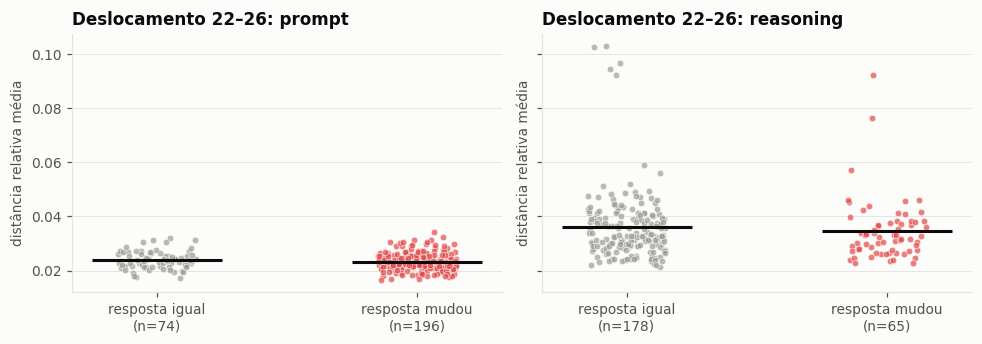

In [24]:
link = []
for r in recs:
    for cond, m in r["compare"].items():
        link.append({"instance_id": r["instance_id"], "condition": cond,
                     "shift_band": m["resid_rel_l2"][BAND[0]:BAND[1] + 1].mean(),
                     "jaccard_band": m["neuron_jaccard"][BAND[0] - 1:BAND[1]].mean()})
link = pd.DataFrame(link).merge(valid[["instance_id", "condition", "changed"]], on=["instance_id", "condition"])
link["scenario"] = link.condition.str.split(":").str[0]
link["resposta"] = link.changed.map({False: "não mudou", True: "mudou"})
display(link.groupby(["scenario", "resposta"]).agg(n=("shift_band", "size"),
                                                   deslocamento=("shift_band", "mean"),
                                                   jaccard=("jaccard_band", "mean")).round(3))

fig, axes = plt.subplots(1, 2, figsize=(9, 3.2), sharey=True)
for ax, scen in zip(axes, ["prompt", "reasoning"]):
    d = link[link.scenario == scen]
    groups = [d[~d.changed].shift_band, d[d.changed].shift_band]
    for i, (vals, color) in enumerate(zip(groups, [CONTROL_COLOR, "#e34948"])):
        jitter = np.random.default_rng(0).uniform(-0.15, 0.15, len(vals))
        ax.scatter(np.full(len(vals), i) + jitter, vals, s=18, color=color, alpha=0.7, edgecolor=SURF, linewidth=0.5)
        if len(vals):
            ax.hlines(vals.mean(), i - 0.25, i + 0.25, color=INK, linewidth=2)
    ax.set_xticks([0, 1], [f"resposta igual\n(n={len(groups[0])})", f"resposta mudou\n(n={len(groups[1])})"])
    ax.set_title(f"Deslocamento {BAND[0]}–{BAND[1]}: {scen}")
    ax.set_ylabel("distância relativa média")
    ax.grid(axis="x", visible=False)
fig.tight_layout()

## 10. Leitura e limitações

- **Comportamento × controle.** A taxa de mudança só indica sensibilidade real
  quando fica acima do controle do mesmo cenário (seção 2.1).
- **Teacher forcing.** As ativações são medidas reapresentando o raciocínio
  **limpo**. Assim elas isolam o efeito da frase sobre a *leitura* da resposta,
  mas não capturam o caso em que a frase desvia o raciocínio para outro
  caminho; esse caso aparece na geração livre (seção 2).
- **Logit lens** é uma leitura aproximada das camadas intermediárias:
  camadas iniciais não "falam" no espaço do vocabulário. A camada de
  convergência é uma medida relativa (com × sem frase), não absoluta.
- **Correlação, não causalidade.** Neurônios e camadas que mudam são
  candidatos; para provar papel causal, o próximo passo é *activation
  patching*: copiar o residual limpo para a condição com frase numa camada e
  ver se a resposta volta.
- **Modelo e amostra:** um modelo por execução (bf16), 90 problemas, uma seed.
- **Tokenização de números:** Qwen quebra números em um token por dígito;
  Llama 3 agrupa até 3 dígitos por token. As análises funcionam por token, então
  em Llama o "ponto de decisão" pode ser um bloco de dígitos.